<a href="https://colab.research.google.com/github/Eligeti-13/Fish_Image_Classification/blob/fish_class/Fish_Image_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import necessary libraries
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
path_dir = "/content/drive/MyDrive/Fish_Image_data"

In [ ]:
# image dataset creation for training and validation


train_dir = "/content/drive/MyDrive/Fish_Image_data/train"
validation_dir = "/content/drive/MyDrive/Fish_Image_data/val"

In [ ]:
# Rescale images to [0, 1] range and applying data augmentation

train_datagen = ImageDataGenerator(
    rescale=1.0/255.0,  # Rescale pixel values to [0, 1]

    # Data Augmentation
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.2,
    height_shift_range=0.2  # Randomly shift images vertically
)

In [ ]:
train_datagen

In [ ]:
# Only rescale for validation data no augmentation required for val data

validation_datagen = ImageDataGenerator(rescale=1.0/255.0)

In [ ]:
# loading images from directory
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),  # Resize images to 224x224
    batch_size=32,
    class_mode='categorical'
)


Found 6234 images belonging to 11 classes.


In [ ]:
validation_generator = validation_datagen.flow_from_directory(
    validation_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

Found 1092 images belonging to 11 classes.


# Model Training

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [ ]:
# Building a CNN model

model = Sequential([

                    Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
                    MaxPooling2D((2, 2)),
                    Conv2D(64, (3, 3), activation='relu'),
                    MaxPooling2D((2, 2)),
                    Conv2D(128, (3, 3), activation='relu'),
                    MaxPooling2D((2, 2)),
                    Flatten(),
                    Dense(512, activation='relu'),
                    Dropout(0.5),
                    Dense(train_generator.num_classes, activation='softmax')
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model

<Sequential name=sequential, built=True>

In [ ]:
# Compiling the model

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
# Training the model

history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // validation_generator.batch_size,
    epochs=10
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
194/194 ━━━━━━━━━━━━━━━━━━━━ 2799s 14s/step - accuracy: 0.2613 - loss: 2.2693 - val_accuracy: 0.4320 - val_loss: 1.6286
Epoch 2/10
  1/194 ━━━━━━━━━━━━━━━━━━━━ 13s 72ms/step - accuracy: 0.4062 - loss: 1.4816

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


194/194 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - accuracy: 0.4062 - loss: 1.4816 - val_accuracy: 0.4265 - val_loss: 1.6413
Epoch 3/10
194/194 ━━━━━━━━━━━━━━━━━━━━ 202s 835ms/step - accuracy: 0.4299 - loss: 1.5588 - val_accuracy: 0.5938 - val_loss: 1.1535
Epoch 4/10
194/194 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.6250 - loss: 1.1166 - val_accuracy: 0.5993 - val_loss: 1.1284
Epoch 5/10
194/194 ━━━━━━━━━━━━━━━━━━━━ 105s 541ms/step - accuracy: 0.5748 - loss: 1.1985 - val_accuracy: 0.7279 - val_loss: 0.8509
Epoch 6/10
194/194 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.7188 - loss: 0.6779 - val_accuracy: 0.7390 - val_loss: 0.8284
Epoch 7/10
194/194 ━━━━━━━━━━━━━━━━━━━━ 142s 731ms/step - accuracy: 0.6757 - loss: 0.9083 - val_accuracy: 0.7463 - val_loss: 0.6718
Epoch 8/10
194/194 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.7188 - loss: 0.6962 - val_accuracy: 0.7574 - val_loss: 0.6413
Epoch 9/10
194/194 ━━━━━━━━━━━━━━━━━━━━ 107s 552ms/step - accuracy: 0.7305 - loss: 0.7673 - val_acc

In [ ]:
# Save the model
import os
os.makedirs(path_dir, exist_ok=True)

In [ ]:
# Save the model
import os
os.makedirs(path_dir, exist_ok=True)

# Defiining the model name
name = 'cnn_model'
save_path = os.path.join(path_dir, f'{name}.h5')

In [ ]:
# Save the model
model.save(save_path)
print(f"Model saved at: {save_path}")

Model saved at: /content/drive/MyDrive/Fish_Image_data/cnn_model.h5


#  Fine-Tune Pre-Trained Models

In [ ]:
from tensorflow.keras.applications import VGG16, ResNet50, MobileNet, InceptionV3, EfficientNetB0
from tensorflow.keras.layers import GlobalAveragePooling2D

# VGG16 Model

In [ ]:
# Load the VGG16 model
vgg_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
model = Sequential([
        vgg_model,
        GlobalAveragePooling2D(),
        Dense(512, activation='relu'),
        Dropout(0.5),
        Dense(train_generator.num_classes, activation='softmax')
])

In [ ]:
# Freezing the base model layers
vgg_model.trainable = False

In [ ]:
# Compiling the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
# Training the model
history = model.fit(
        train_generator,
        steps_per_epoch=train_generator.samples // train_generator.batch_size,
        validation_data=validation_generator,
        validation_steps=validation_generator.samples // validation_generator.batch_size,
        epochs=5
)


Epoch 1/5
194/194 ━━━━━━━━━━━━━━━━━━━━ 2855s 15s/step - accuracy: 0.3543 - loss: 1.8881 - val_accuracy: 0.7638 - val_loss: 0.9401
Epoch 2/5
  1/194 ━━━━━━━━━━━━━━━━━━━━ 31s 163ms/step - accuracy: 0.8125 - loss: 0.7553

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


194/194 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - accuracy: 0.8125 - loss: 0.7553 - val_accuracy: 0.7555 - val_loss: 0.9426
Epoch 3/5
194/194 ━━━━━━━━━━━━━━━━━━━━ 164s 632ms/step - accuracy: 0.6983 - loss: 0.9483 - val_accuracy: 0.8290 - val_loss: 0.5933
Epoch 4/5
194/194 ━━━━━━━━━━━━━━━━━━━━ 7s 35ms/step - accuracy: 0.6562 - loss: 0.9412 - val_accuracy: 0.8428 - val_loss: 0.5764
Epoch 5/5
194/194 ━━━━━━━━━━━━━━━━━━━━ 124s 639ms/step - accuracy: 0.8074 - loss: 0.6411 - val_accuracy: 0.8906 - val_loss: 0.4103


In [ ]:
name = 'VGG16'
save_path = os.path.join(path_dir, f'{name}_fine_tuned.h5')
# Save the model
model.save(save_path)

# ResNet50 Tuned Model

In [ ]:
# Load the VGG16 model
ResNet50 = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
model = Sequential([
        ResNet50,
        GlobalAveragePooling2D(),
        Dense(512, activation='relu'),
        Dropout(0.5),
        Dense(train_generator.num_classes, activation='softmax')
])

In [ ]:
# Freezing the base model layers
ResNet50.trainable = False

In [ ]:
# Compiling the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
# Training the model
history = model.fit(
        train_generator,
        steps_per_epoch=train_generator.samples // train_generator.batch_size,
        validation_data=validation_generator,
        validation_steps=validation_generator.samples // validation_generator.batch_size,
        epochs=5
)


Epoch 1/5
194/194 ━━━━━━━━━━━━━━━━━━━━ 164s 757ms/step - accuracy: 0.1430 - loss: 2.4596 - val_accuracy: 0.1710 - val_loss: 2.2290
Epoch 2/5
194/194 ━━━━━━━━━━━━━━━━━━━━ 8s 40ms/step - accuracy: 0.1875 - loss: 2.2776 - val_accuracy: 0.1710 - val_loss: 2.2325
Epoch 3/5
194/194 ━━━━━━━━━━━━━━━━━━━━ 120s 620ms/step - accuracy: 0.1824 - loss: 2.2425 - val_accuracy: 0.1967 - val_loss: 2.1576
Epoch 4/5
194/194 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.1875 - loss: 2.1708 - val_accuracy: 0.1949 - val_loss: 2.1550
Epoch 5/5
194/194 ━━━━━━━━━━━━━━━━━━━━ 144s 657ms/step - accuracy: 0.1944 - loss: 2.1877 - val_accuracy: 0.1682 - val_loss: 2.1133


In [ ]:
name = 'ResNet50'
save_path = os.path.join(path_dir, f'{name}_fine_tuned.h5')
# Save the model
model.save(save_path)

# MobileNet

In [ ]:
# Load the VGG16 model
MobileNet = MobileNet(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
model = Sequential([
        MobileNet,
        GlobalAveragePooling2D(),
        Dense(512, activation='relu'),
        Dropout(0.5),
        Dense(train_generator.num_classes, activation='softmax')
])

In [ ]:
# Freezing the base model layers
MobileNet.trainable = False

In [ ]:
# Compiling the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
# Training the model
history = model.fit(
        train_generator,
        steps_per_epoch=train_generator.samples // train_generator.batch_size,
        validation_data=validation_generator,
        validation_steps=validation_generator.samples // validation_generator.batch_size,
        epochs=5
)


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
194/194 ━━━━━━━━━━━━━━━━━━━━ 2610s 13s/step - accuracy: 0.6763 - loss: 1.0520 - val_accuracy: 0.9789 - val_loss: 0.0889
Epoch 2/5
  1/194 ━━━━━━━━━━━━━━━━━━━━ 21:37 7s/step - accuracy: 0.9375 - loss: 0.2609

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


194/194 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - accuracy: 0.9375 - loss: 0.2609 - val_accuracy: 0.9770 - val_loss: 0.0888
Epoch 3/5
194/194 ━━━━━━━━━━━━━━━━━━━━ 143s 507ms/step - accuracy: 0.9428 - loss: 0.1725 - val_accuracy: 0.9825 - val_loss: 0.0465
Epoch 4/5
194/194 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.9688 - loss: 0.0879 - val_accuracy: 0.9853 - val_loss: 0.0462
Epoch 5/5
194/194 ━━━━━━━━━━━━━━━━━━━━ 142s 733ms/step - accuracy: 0.9632 - loss: 0.1153 - val_accuracy: 0.9871 - val_loss: 0.0474


In [ ]:
name = 'MobileNet'
save_path = os.path.join(path_dir, f'{name}_fine_tuned.h5')
# Save the model
model.save(save_path)

# InceptionV3

In [ ]:
# Load the VGG16 model
InceptionV3 = InceptionV3(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
model = Sequential([
        InceptionV3,
        GlobalAveragePooling2D(),
        Dense(512, activation='relu'),
        Dropout(0.5),
        Dense(train_generator.num_classes, activation='softmax')
])

In [ ]:
# Freezing the base model layers
InceptionV3.trainable = False

In [ ]:
# Compiling the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
# Training the model
history = model.fit(
        train_generator,
        steps_per_epoch=train_generator.samples // train_generator.batch_size,
        validation_data=validation_generator,
        validation_steps=validation_generator.samples // validation_generator.batch_size,
        epochs=5
)

Epoch 1/5
194/194 ━━━━━━━━━━━━━━━━━━━━ 148s 672ms/step - accuracy: 0.5980 - loss: 1.4199 - val_accuracy: 0.9062 - val_loss: 0.3060
Epoch 2/5
194/194 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.7500 - loss: 0.6095 - val_accuracy: 0.9090 - val_loss: 0.2968
Epoch 3/5
194/194 ━━━━━━━━━━━━━━━━━━━━ 176s 612ms/step - accuracy: 0.8640 - loss: 0.4112 - val_accuracy: 0.9228 - val_loss: 0.2173
Epoch 4/5
194/194 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.8750 - loss: 0.5935 - val_accuracy: 0.9182 - val_loss: 0.2252
Epoch 5/5
194/194 ━━━━━━━━━━━━━━━━━━━━ 136s 611ms/step - accuracy: 0.8949 - loss: 0.3189 - val_accuracy: 0.9605 - val_loss: 0.1419


In [ ]:
name = 'InceptionV3'
save_path = os.path.join(path_dir, f'{name}_fine_tuned.h5')
# Save the model
model.save(save_path)

# EfficientNetB0

In [ ]:
# Load the VGG16 model
EfficientNetB0 = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
model = Sequential([
        EfficientNetB0,
        GlobalAveragePooling2D(),
        Dense(512, activation='relu'),
        Dropout(0.5),
        Dense(train_generator.num_classes, activation='softmax')
])

In [ ]:
# Freezing the base model layers
EfficientNetB0.trainable = False

In [ ]:
# Compiling the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
# Training the model
history = model.fit(
        train_generator,
        steps_per_epoch=train_generator.samples // train_generator.batch_size,
        validation_data=validation_generator,
        validation_steps=validation_generator.samples // validation_generator.batch_size,
        epochs=5
)

Epoch 1/5
194/194 ━━━━━━━━━━━━━━━━━━━━ 167s 703ms/step - accuracy: 0.1540 - loss: 2.3686 - val_accuracy: 0.1710 - val_loss: 2.3129
Epoch 2/5
194/194 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - accuracy: 0.1250 - loss: 2.3041 - val_accuracy: 0.1719 - val_loss: 2.3123
Epoch 3/5
194/194 ━━━━━━━━━━━━━━━━━━━━ 141s 729ms/step - accuracy: 0.1733 - loss: 2.3148 - val_accuracy: 0.1719 - val_loss: 2.3149
Epoch 4/5
194/194 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.2500 - loss: 2.2468 - val_accuracy: 0.1719 - val_loss: 2.3149
Epoch 5/5
194/194 ━━━━━━━━━━━━━━━━━━━━ 170s 594ms/step - accuracy: 0.1800 - loss: 2.3082 - val_accuracy: 0.1710 - val_loss: 2.3129


In [ ]:
name = 'EfficientNetB0'
save_path = os.path.join(path_dir, f'{name}_fine_tuned.h5')
# Save the model
model.save(save_path)

- The best model from above five pre-trained models are:
- MobileNet - Due to Highest accuracy and lowest loss than other models

# Fine-Tuning the MobileNet Model Using Learning Rate

In [ ]:
# Loading MobileNet without the top layer
Fine_tune_model = MobileNet(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Freezing the base model layers
Fine_tune_model.trainable = False

In [ ]:
# Build the model with custom layers
model = Sequential([
                  Fine_tune_model,
                  GlobalAveragePooling2D(),
                  Dense(512, activation='relu'),
                  Dropout(0.5),
                  Dense(256, activation='relu'),
                  Dropout(0.3),
                  Dense(train_generator.num_classes, activation='softmax')
])

In [ ]:
from tensorflow.keras.optimizers import SGD

In [ ]:
# Compile the model with SGD optimizer and learning rate 0.001
model.compile(optimizer=SGD(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
# Training the model
history = model.fit(
        train_generator,
        steps_per_epoch=train_generator.samples // train_generator.batch_size,
        validation_data=validation_generator,
        validation_steps=validation_generator.samples // validation_generator.batch_size,
        epochs=5
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
194/194 ━━━━━━━━━━━━━━━━━━━━ 2185s 11s/step - accuracy: 0.1414 - loss: 2.7718 - val_accuracy: 0.5000 - val_loss: 1.7725
Epoch 2/5
  1/194 ━━━━━━━━━━━━━━━━━━━━ 4:17 1s/step - accuracy: 0.3438 - loss: 1.8643

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


194/194 ━━━━━━━━━━━━━━━━━━━━ 55s 279ms/step - accuracy: 0.3438 - loss: 1.8643 - val_accuracy: 0.5046 - val_loss: 1.7725
Epoch 3/5
194/194 ━━━━━━━━━━━━━━━━━━━━ 432s 2s/step - accuracy: 0.2974 - loss: 2.0745 - val_accuracy: 0.7050 - val_loss: 1.4257
Epoch 4/5
194/194 ━━━━━━━━━━━━━━━━━━━━ 55s 280ms/step - accuracy: 0.4375 - loss: 1.6465 - val_accuracy: 0.7004 - val_loss: 1.4261
Epoch 5/5
194/194 ━━━━━━━━━━━━━━━━━━━━ 502s 3s/step - accuracy: 0.4074 - loss: 1.7252 - val_accuracy: 0.8015 - val_loss: 1.1803


In [ ]:
name = 'max accuracy model'
save_path = os.path.join(path_dir, f'{name}_fine_tuned.h5')
# Save the model
model.save(save_path)

In [ ]:
# Unfreeze some layers for fine-tuning
for layer in Fine_tune_model.layers[-20:]:
    layer.trainable = True

In [ ]:
# Recompile with SGD and a lower learning rate (e.g., 0.0001)
model.compile(optimizer=SGD(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
# Training the model
history = model.fit(
        train_generator,
        steps_per_epoch=train_generator.samples // train_generator.batch_size,
        validation_data=validation_generator,
        validation_steps=validation_generator.samples // validation_generator.batch_size,
        epochs=5
)

Epoch 1/5
194/194 ━━━━━━━━━━━━━━━━━━━━ 576s 3s/step - accuracy: 0.2543 - loss: 2.2279 - val_accuracy: 0.7316 - val_loss: 1.3613
Epoch 2/5
194/194 ━━━━━━━━━━━━━━━━━━━━ 80s 407ms/step - accuracy: 0.4615 - loss: 1.8625 - val_accuracy: 0.7316 - val_loss: 1.3636
Epoch 3/5
194/194 ━━━━━━━━━━━━━━━━━━━━ 587s 3s/step - accuracy: 0.3509 - loss: 1.8456 - val_accuracy: 0.7344 - val_loss: 1.3654
Epoch 4/5
194/194 ━━━━━━━━━━━━━━━━━━━━ 53s 260ms/step - accuracy: 0.2500 - loss: 2.1464 - val_accuracy: 0.7353 - val_loss: 1.3640
Epoch 5/5
194/194 ━━━━━━━━━━━━━━━━━━━━ 570s 3s/step - accuracy: 0.3945 - loss: 1.7799 - val_accuracy: 0.7555 - val_loss: 1.3218


In [ ]:
name = 'max accuracy model unfreezing'
save_path = os.path.join(path_dir, f'{name}_fine_tuned.h5')
# Save the model
model.save(save_path)

- unfreezing the data is not effective for dataset

# Model Evaluation

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

In [ ]:
# Load the best model (e.g., EfficientNetB0)
model = tf.keras.models.load_model('/content/drive/MyDrive/Fish_Image_data/MobileNet_fine_tuned.h5')

In [ ]:
# Evaluate the model on the validation set
validation_generator.reset()
predictions = model.predict(validation_generator)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = validation_generator.classes
class_labels = list(validation_generator.class_indices.keys())

35/35 ━━━━━━━━━━━━━━━━━━━━ 11s 219ms/step


In [ ]:
# Print classification report
print("Classification Report:")
print(classification_report(true_classes, predicted_classes, target_names=class_labels))

Classification Report:
                                  precision    recall  f1-score   support

                     animal fish       0.20      0.20      0.20       187
                animal fish bass       0.00      0.00      0.00        10
   fish sea_food black_sea_sprat       0.10      0.10      0.10       105
   fish sea_food gilt_head_bream       0.07      0.07      0.07        94
   fish sea_food hourse_mackerel       0.12      0.12      0.12        97
        fish sea_food red_mullet       0.11      0.11      0.11        90
     fish sea_food red_sea_bream       0.07      0.07      0.07       113
          fish sea_food sea_bass       0.13      0.13      0.13        97
            fish sea_food shrimp       0.12      0.12      0.12       100
fish sea_food striped_red_mullet       0.13      0.12      0.12       101
             fish sea_food trout       0.07      0.07      0.07        98

                        accuracy                           0.12      1092
             

In [ ]:
# Print confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(true_classes, predicted_classes))

Confusion Matrix:
[[37  1 13 19 20 14 26 13 17 16 11]
 [ 0  0  1  0  1  1  1  1  2  1  2]
 [22  0 11 10  8  5 10  8  7 11 13]
 [19  0  7  7 13  8 13  9  7  5  6]
 [14  1  8  4 12 10  9  7  5 12 15]
 [20  2 10  9  8 10  2 10  9  5  5]
 [16  1 14 11 10 14  8  7 13 10  9]
 [11  0 14  5  5  6 17 13  8  3 15]
 [18  0 11 11  8  6  6  9 12 12  7]
 [16  0 13 10  6 10 12  7  7 12  8]
 [15  1  4  8  7 11  9 14 14  8  7]]


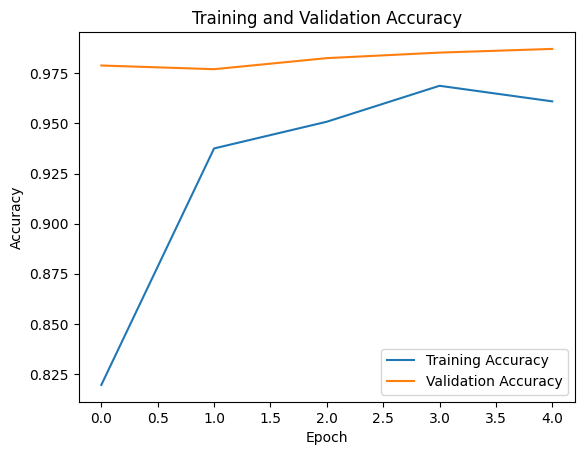

In [ ]:
# Plot training history
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Streamlit App

In [10]:
!pip install -q streamlit

In [17]:
%%writefile app.py
import streamlit as st
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import os

# Load the saved model
model = load_model('/content/drive/MyDrive/Fish_Image_data/MobileNet_fine_tuned.h5')

# Get class labels automatically from directory structure
def get_class_labels(directory):
    datagen = ImageDataGenerator()
    generator = datagen.flow_from_directory(
        directory,
        target_size=(224, 224),
        batch_size=1,
        class_mode='categorical',
        shuffle=False
    )
    return list(generator.class_indices.keys())

DATA_DIR = '/content/drive/MyDrive/Fish_Image_data/val'
class_labels = get_class_labels(DATA_DIR)

# Streamlit app with navigation
st.sidebar.title("Navigation")
page = st.sidebar.radio("Go to", ["Home", "Image Classification"])

if page == "Home":
    st.title("Fish Classification App")
    st.write("""
    Welcome to the Fish Classification App! 🐟
    This application uses a deep learning model to classify images of fish into different categories.
    Just head over to the **Image Classification** section, upload an image, and let the AI predict the fish type for you.
    """)
elif page == "Image Classification":
  # Streamlit app
  st.title("Fish Classification App")
  st.write("Upload an image of a fish, and the model will predict its category.")


  # File uploader
  uploaded_file = st.file_uploader("Choose an image...", type=["jpg", "jpeg", "png"])
  if uploaded_file is not None:
      # Display the uploaded image
      st.image(uploaded_file, caption='Uploaded Image',  use_container_width=True)

      # Preprocess the image
      img = image.load_img(uploaded_file, target_size=(224, 224))
      img_array = image.img_to_array(img)
      img_array = np.expand_dims(img_array, axis=0) / 255.0  # Rescale to [0, 1]

      # Make a prediction
      predictions = model.predict(img_array)
      predicted_class = np.argmax(predictions)
      confidence = np.max(predictions)

      # Display the result
      st.success(f"Predicted Fish: {class_labels[predicted_class]}")
      st.info(f"Confidence: {confidence:.2%}")  # Shows as percentage

Overwriting app.py


In [15]:
! wget -q -O - ipv4.icanhazip.com

34.125.117.249


In [ ]:
! streamlit run app.py & npx localtunnel --port 8501



⠙⠹⠸⠼
  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.125.117.249:8501

⠴your url is: https://hungry-pets-act.loca.lt
2025-05-26 07:35:56.402424: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1748244956.424695   18723 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1748244956.431381   18723 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-05-26 07:36:00.110711: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value w